In [21]:
import pandas as pd
import numpy as np
import anndata
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# turn off warnings
import warnings
warnings.filterwarnings("ignore")

base_path = "../data/liver_marker_genes"


### Liver marker genes from the atlas

In this notebook, we will extract marker genes from the liver cell atlas. The spreadsheets with the markers are located in the GPU cluster, at `/srv/scratch/lottep/LiverMarkerGenes/forLotte`. These genes are obtained by performing differential expression between different clusters in the single-cell data. They are also downloadable from the supplementary data of the [spatial proteogenomics paper (Guilliams et al, 2024)](https://www.sciencedirect.com/science/article/pii/S0092867421014811?via%3Dihub). Let's first look at the markers for the entire mouse steady-state dataset. The code in this section has been adapted from the notebook `/srv/scratch/lottep/vizgen/CreateMarkerGeneListVizgen.ipynb`.

In [22]:
df = pd.read_excel(f'{base_path}/markers_mouseStStAll.xlsx', index_col=0,sheet_name=None) 

df

{'cl0':          proba_de  proba_not_de  bayes_factor    scale1    scale2  lfc_mean  \
 Gm10600  0.997786      0.002214      6.110656  0.000139  0.000003  8.160881   
 Fbxl7    0.999799      0.000201      8.510522  0.002027  0.000018  8.248190   
 Ptprb    1.000000      0.000000     18.420681  0.007883  0.000071  7.954790   
 Lama4    0.998188      0.001812      6.311729  0.000595  0.000012  7.877245   
 Wnt2     0.997585      0.002415      6.023443  0.000701  0.000009  7.700866   
 ...           ...           ...           ...       ...       ...       ...   
 Slfn5    0.923712      0.076288      2.493881  0.000914  0.000419  2.395332   
 Ecm1     0.927134      0.072866      2.543471  0.000169  0.000402  1.651428   
 Hes1     0.916063      0.083937      2.390016  0.000540  0.000241  1.806278   
 Stard9   0.886071      0.113929      2.051220  0.000266  0.000123  2.459893   
 Map4k4   0.879630      0.120370      1.988927  0.000545  0.000289  1.754935   
 
          lfc_median   lfc_std 

In [23]:
# Don't filter
# ext = "_all"
# filtered_df = df

# Filter rows for each cluster where 'proba_not_de' <= 0.01
# filtered_df = {cluster: data[data['proba_not_de'] <= 0.01] for cluster, data in df.items()}
# ext = "_filtered1e-2"

# Filter rows for each cluster where score is top 10% percentile of that cluster
# filtered_df = {cluster: data[data['score'] >= data['score'].quantile(0.9)] for cluster, data in df.items()}
# ext = "_q90"

# Filter rows for each cluster where score is top 50% percentile of that cluster
filtered_df = {cluster: data[data['score'] >= data['score'].quantile(0.5)] for cluster, data in df.items()}
ext = "_q50"

In [24]:
num_rows = {cluster: len(data) for cluster, data in filtered_df.items()}
num_rows_ori = {cluster: len(data) for cluster, data in df.items()}
pd.DataFrame({'Filtered': num_rows, 'Original': num_rows_ori})

,Filtered,Original
cl0,272,543
cl1,209,418
cl2,375,750
cl3,281,561
cl4,152,303
cl5,154,307
cl6,141,282
cl7,155,309
cl8,157,314
cl9,160,319


In [25]:
df = filtered_df

In [26]:
# Get all unique gene names from all sheets
geneNames=[]
for i in df.keys():
    geneNames.extend(df[i].index.values)

geneNames=np.array(geneNames)
indexGenes=np.unique(geneNames)

The excel sheet contains 17 clusters, which are labeled just with numbers. To get the name of the cell types, you must cross-check with the UMAP. Then, we can create a one-hot encoded matrix.

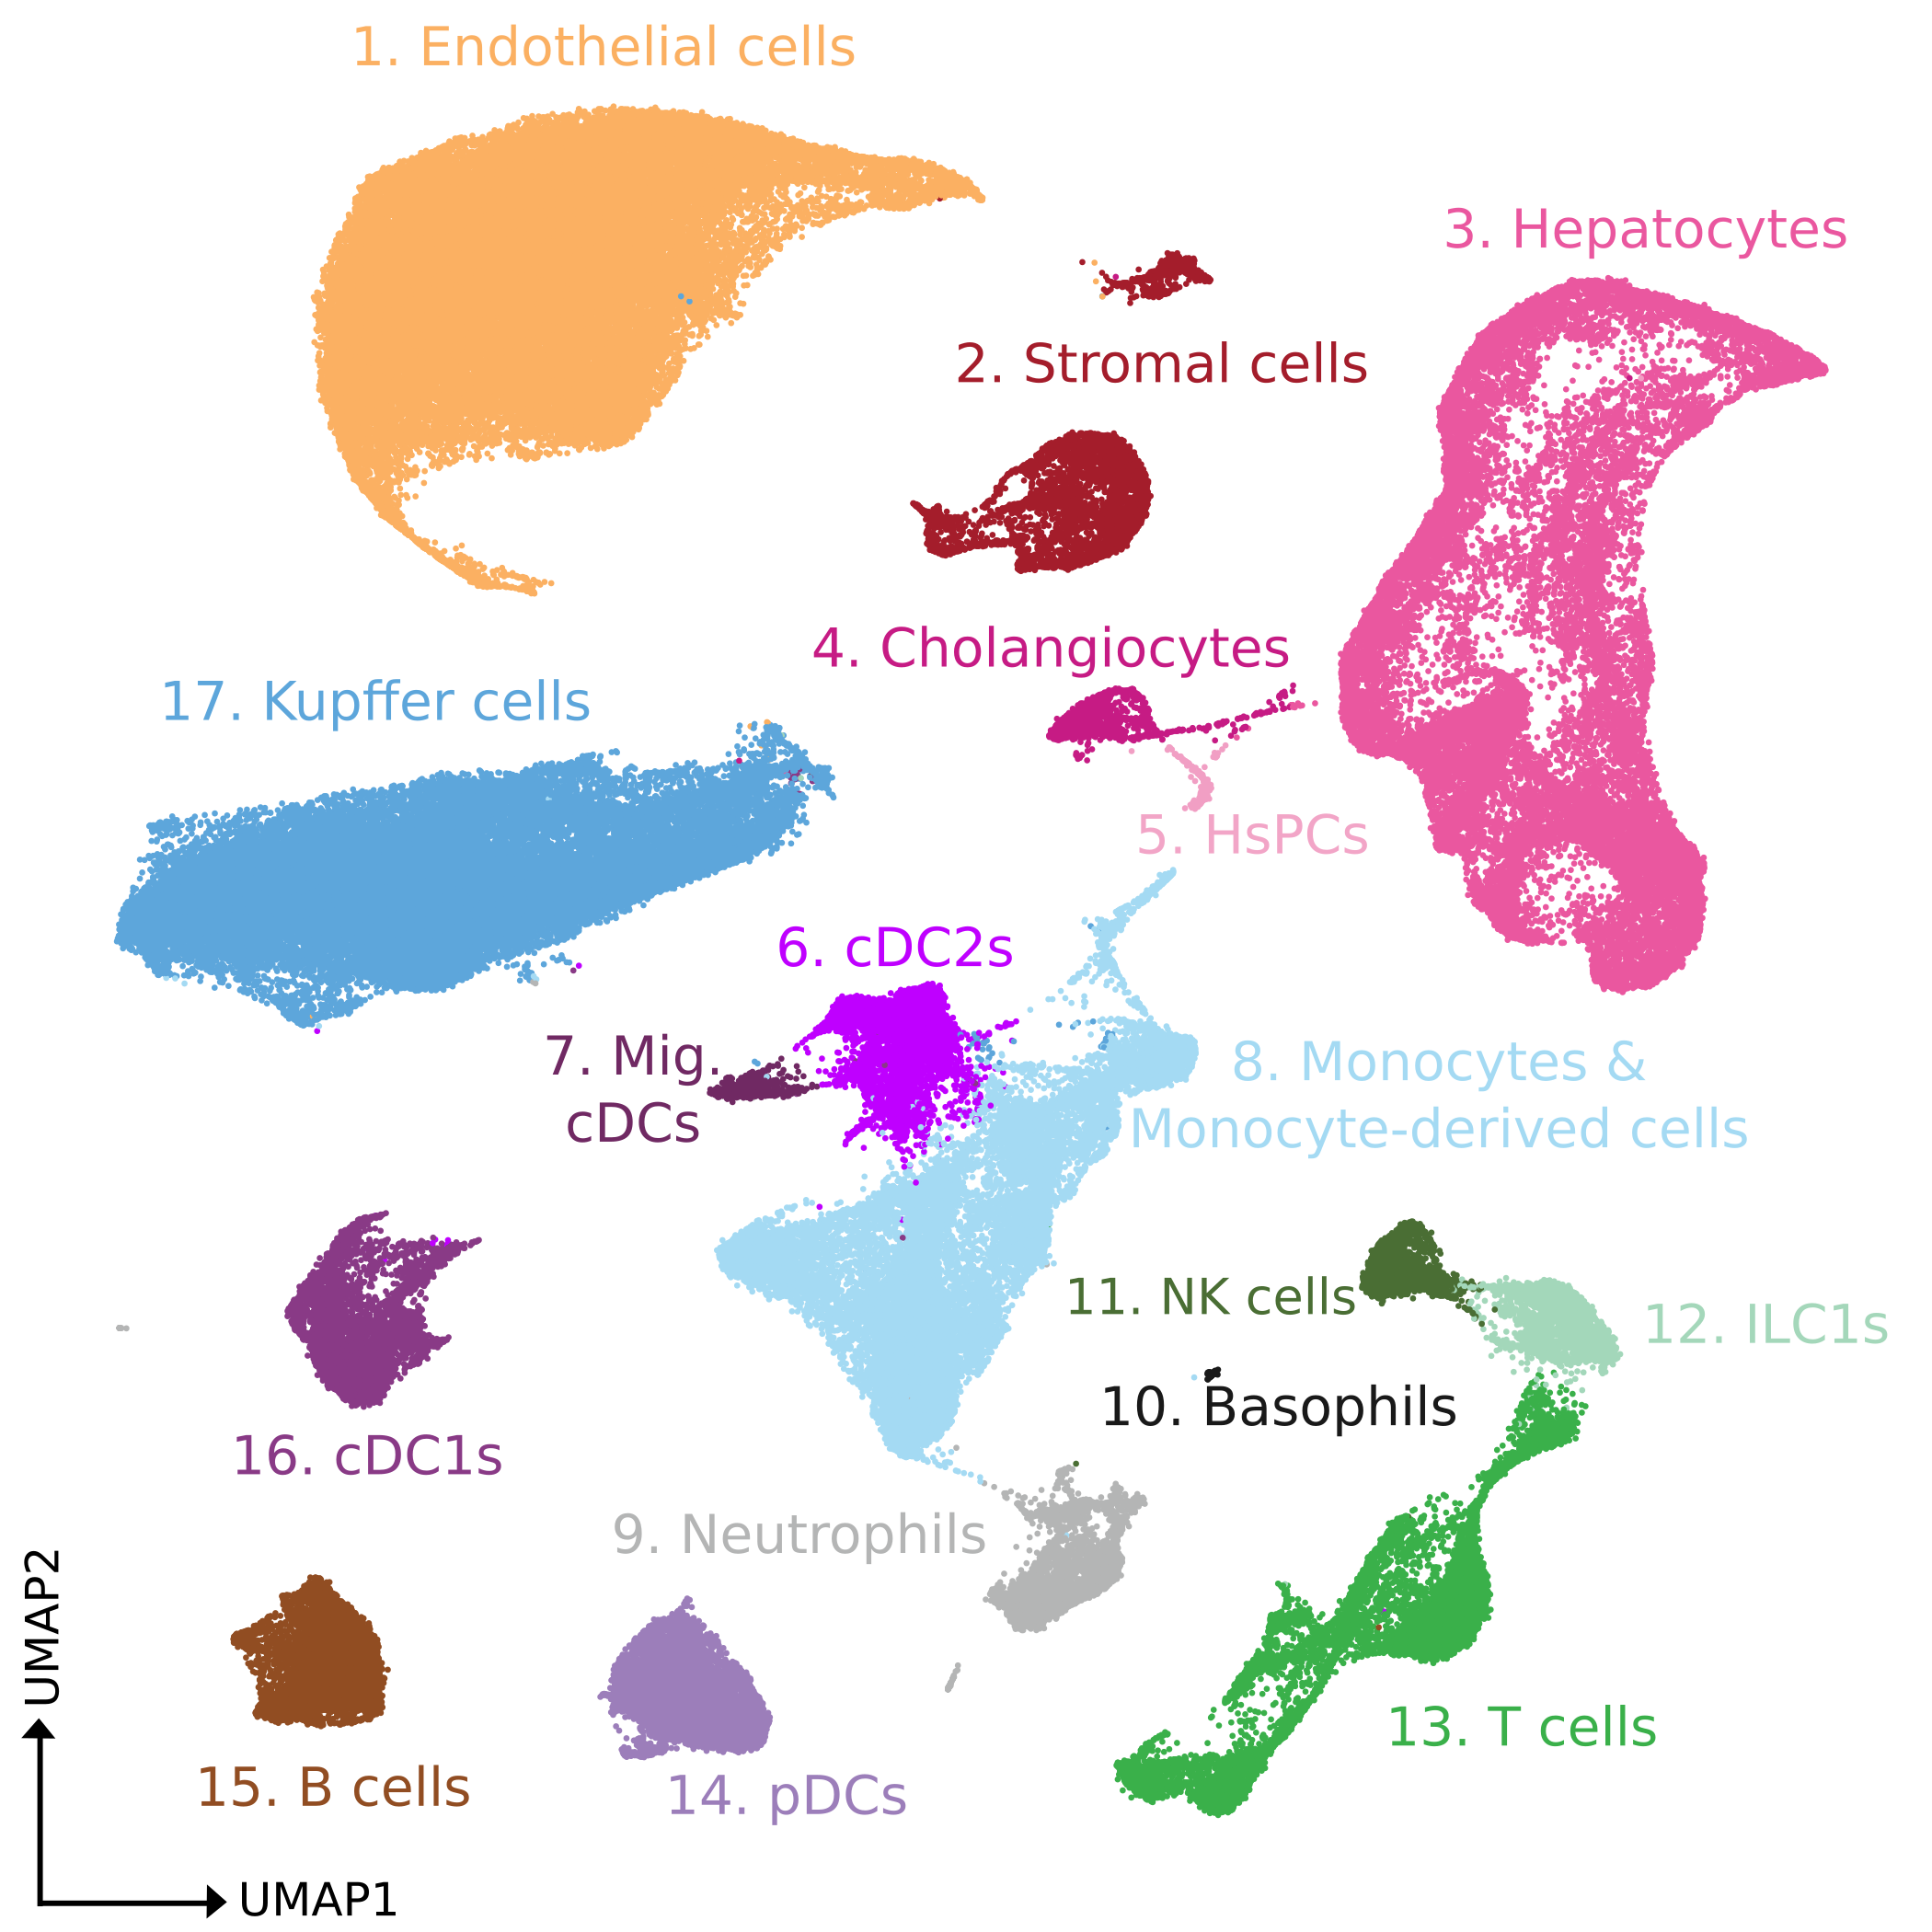

In [27]:
from IPython.display import Image
Image(filename=f'{base_path}/umap_mouseStStAll.png',width=400) 

In [28]:
celltypesAll=['Endothelial cells','Stromal cells','Hepatocytes','Cholangiocytes','HsPCs','cDC2s','Mig. cDCs',
              'Monocytes and Monocytes-derived cells','Neutrophils','Basophils','NK cells','ILC1s','T cells',
              'pDCs','B cells','cDC1s','Kupffer cells']

df_onehot = pd.DataFrame(index = pd.Index(indexGenes))


In [29]:
for i, cluster in enumerate(df.keys()):
    # Initialize all columns to zero
    nameCol = celltypesAll[i]
    df_onehot[nameCol] = 0
    
    # Set to 1 where the gene is present in the current cluster
    df_onehot.loc[df[cluster].index, nameCol] = 1

In [30]:
# Sanity check: that there are no rows that are all zero
np.sum(df_onehot.sum(axis=1) == 0)

0

In [31]:
# Remove spaces and dots in the column names
df_onehot.columns = df_onehot.columns.str.replace(' ', '').str.replace('.', '').str.replace('-', '')

# Save this (without merscope panel)
df_onehot.to_csv(f'{base_path}/markers_mouseStStAll_onehot{ext}.csv')

In [32]:
# Check intersection of genes with VisiumHD data
adata = anndata.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr/tables/square_008um')

# Check how many genes in sdata are in common with dfTotRank_merge
genes_in_adata = df_onehot.index.intersection(adata.var_names)

In [33]:
print(f"{len(genes_in_adata)} out of {df_onehot.shape[0]} marker genes are present in Anndata")

# All genes are affected a little bit
pd.DataFrame({
    'All marker genes': df_onehot.astype(bool).sum(axis=0),
    'Present in anndata': df_onehot.loc[genes_in_adata].astype(bool).sum(axis=0)
})


1899 out of 2030 marker genes are present in Anndata


,All marker genes,Present in anndata
Endothelialcells,272,261
Stromalcells,209,200
Hepatocytes,375,340
Cholangiocytes,281,266
HsPCs,152,145
cDC2s,154,145
MigcDCs,141,137
MonocytesandMonocytesderivedcells,155,145
Neutrophils,157,139
Basophils,160,148


#### MERSCOPE panel

Next, we will check the concordance between the MERSCOPE panel from the Guilliams lab (provided by Michiel) with the marker genes from scRNA-seq.

In [ ]:
merscope_markers = pd.read_csv('../data/liver_marker_genes/final_MERscope_panel_Guilliams1.csv')

# Genes of interest are ones that start with 'cellType_
print(merscope_markers['Notes'][merscope_markers['Notes'].str.startswith('cellType_')].value_counts())

merscope_markers = merscope_markers[merscope_markers['Notes'].str.startswith('cellType_')]

Notes
cellType_stellate              35
cellType_LSEC                  33
cellType_fibroblast            32
cellType_KC                    28
cellType_TCell                 27
cellType_hepatocyte            19
cellType_neutrophil            19
cellType_coreMacrophage        16
cellType_monocyte              14
cellType_basophil              13
cellType_cDC2                  12
cellType_cholangiocyte         12
cellType_cDC1                  12
cellType_LAM                   11
cellType_otherMacrophage       10
cellType_BCell                 10
cellType_DCMig                  9
cellType_pDC                    9
cellType_mesothelial            9
cellType_coreEndothelial        7
cellType_ILC1                   7
cellType_NKCell                 7
cellType_MSC                    7
cellType_coreMesenchymal        6
cellType_veins                  6
cellType_VSMC                   5
cellType_LEC                    4
cellType_HpSC                   4
cellType_monocytePatrolling     3
cellType

In [13]:
# Turn marker_gene_subset into a one-hot encoded dataframe, with cell type names in the first row, and marker genes in the columns
merscope_markers_onehot = merscope_markers.pivot(index='Notes', columns='Vizgen Gene', values='Vizgen Gene').fillna(0)
# Turn string to 1
merscope_markers_onehot = merscope_markers_onehot.applymap(lambda x: 1 if x != 0 else 0)
# Remove "cellType_" from the index
merscope_markers_onehot.index = merscope_markers_onehot.index.str.replace('cellType_', '')
# Transpose this
merscope_markers_onehot = merscope_markers_onehot.T
merscope_markers_onehot


Notes,BCell,DCMig,HpSC,ILC1,KC,LAM,LEC,LSEC,MSC,NKCell,...,fibroblast,hepatocyte,mesothelial,monocyte,monocytePatrolling,neutrophil,otherMacrophage,pDC,stellate,veins
Vizgen Gene,,,,,,,,,,,,,,,,,,,,,
Acp5,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Acta2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
Adgre1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Adh4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
Aldh1a2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wt1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Wwox,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
Xcl1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# Check column names of both dataframes
print("Liver marker genes columns:", df_onehot.columns)
print("MERScope marker genes columns:", merscope_markers_onehot.columns)

Liver marker genes columns: Index(['Endothelial cells', 'Stromal cells', 'Hepatocytes', 'Cholangiocytes',
       'HsPCs', 'cDC2s', 'Mig. cDCs', 'Monocytes and Monocytes-derived cells',
       'Neutrophils', 'Basophils', 'NK cells', 'ILC1s', 'T cells', 'pDCs',
       'B cells', 'cDC1s', 'Kupffer cells'],
      dtype='object')
MERScope marker genes columns: Index(['BCell', 'DCMig', 'HpSC', 'ILC1', 'KC', 'LAM', 'LEC', 'LSEC', 'MSC',
       'NKCell', 'TCell', 'VSMC', 'allImmune', 'allImmune_Cd45', 'basophil',
       'cDC1', 'cDC2', 'cholangiocyte', 'coreEndothelial', 'coreMacrophage',
       'coreMesenchymal', 'eosinophil', 'fibroblast', 'hepatocyte',
       'mesothelial', 'monocyte', 'monocytePatrolling', 'neutrophil',
       'otherMacrophage', 'pDC', 'stellate', 'veins'],
      dtype='object', name='Notes')


In [15]:
# Rename columns of merscope_markers_onehot to match df_onehot
merscope_markers_onehot = merscope_markers_onehot.rename(columns={
    'BCell': 'B cells',
    'DCMig': 'Mig. cDCs',
    'HpSC': 'HsPCs',
    'ILC1': 'ILC1s',
    'KC': 'Kupffer cells',
    'LEC': 'Lymphatic Endothelial cells',
    'LSEC': 'LSECs',
    'NKCell': 'NK cells',
    'TCell': 'T cells',
    'basophil': 'Basophils',
    'cDC1': 'cDC1s',
    'cDC2': 'cDC2s',
    'cholangiocyte': 'Cholangiocytes',
    'coreEndothelial': 'Endothelial cells',
    'fibroblast': 'Stromal cells',
    'hepatocyte': 'Hepatocytes',
    'mesothelial': 'Mesothelial cells',
    'monocyte': 'Monocytes and Monocytes-derived cells',
    'neutrophil': 'Neutrophils',
    'stellate': 'Stellate cells',
    'pDC': 'pDCs'
})

In [16]:
# Get intersection of columns in df_onehot and merscope_markers_onehot
print("Common cell types:", df_onehot.columns.intersection(merscope_markers_onehot.columns))

# Which column in df_onehot is not in merscope_markers_onehot?
print("Cell types in liver markers but not in MERSCOPE markers:",
        df_onehot.columns.difference(merscope_markers_onehot.columns)) 

# Which column in merscope_markers_onehot is not in df_onehot?
print("Cell types in MERSCOPE markers but not in liver markers:",
        merscope_markers_onehot.columns.difference(df_onehot.columns))

Common cell types: Index(['Endothelial cells', 'Stromal cells', 'Hepatocytes', 'Cholangiocytes',
       'HsPCs', 'cDC2s', 'Mig. cDCs', 'Monocytes and Monocytes-derived cells',
       'Neutrophils', 'Basophils', 'NK cells', 'ILC1s', 'T cells', 'pDCs',
       'B cells', 'cDC1s', 'Kupffer cells'],
      dtype='object')
Cell types in liver markers but not in MERSCOPE markers: Index([], dtype='object')
Cell types in MERSCOPE markers but not in liver markers: Index(['LAM', 'LSECs', 'Lymphatic Endothelial cells', 'MSC',
       'Mesothelial cells', 'Stellate cells', 'VSMC', 'allImmune',
       'allImmune_Cd45', 'coreMacrophage', 'coreMesenchymal', 'eosinophil',
       'monocytePatrolling', 'otherMacrophage', 'veins'],
      dtype='object')


3 Endothelial cells genes in MERSCOPE not in atlas:
['Klf4' 'Pecam1' 'Timp3']

22 Stromal cells genes in MERSCOPE not in atlas:
['Acta2' 'Ccl11' 'Cd34' 'Clec3b' 'Clic5' 'Des' 'Dpep1' 'Dpt' 'Ebf1' 'Gfap'
 'Gpx3' 'Lox' 'Loxl1' 'Mfap4' 'Myh11' 'Ncam1' 'Penk' 'Pi16' 'Pln' 'Svep1'
 'Tpm2' 'Wnt5a']

12 Hepatocytes genes in MERSCOPE not in atlas:
['Adh4' 'Angptl3' 'Etv6' 'F9' 'Gls2' 'Hacl1' 'Hnf4a' 'Large1' 'Onecut1'
 'Onecut2' 'Pck1' 'Wwox']

3 Cholangiocytes genes in MERSCOPE not in atlas:
['Bmp7' 'Pdgfa' 'Pdgfc']

2 HsPCs genes in MERSCOPE not in atlas:
['Kcnb2' 'Tox3']

3 cDC2s genes in MERSCOPE not in atlas:
['Irf4' 'Itgam' 'Sirpa']

3 Monocytes and Monocytes-derived cells genes in MERSCOPE not in atlas:
['Fn1' 'Napsa' 'Rbpj']

9 Neutrophils genes in MERSCOPE not in atlas:
['Anxa1' 'Cxcr4' 'Hmgb2' 'Ly6g' 'Pglyrp1' 'Selplg' 'Tgfbi' 'Tspan13' 'Zyx']

2 Basophils genes in MERSCOPE not in atlas:
['Gpr183' 'Mcpt8']

1 NK cells genes in MERSCOPE not in atlas:
['Ifng']

12 T cells genes in MERS

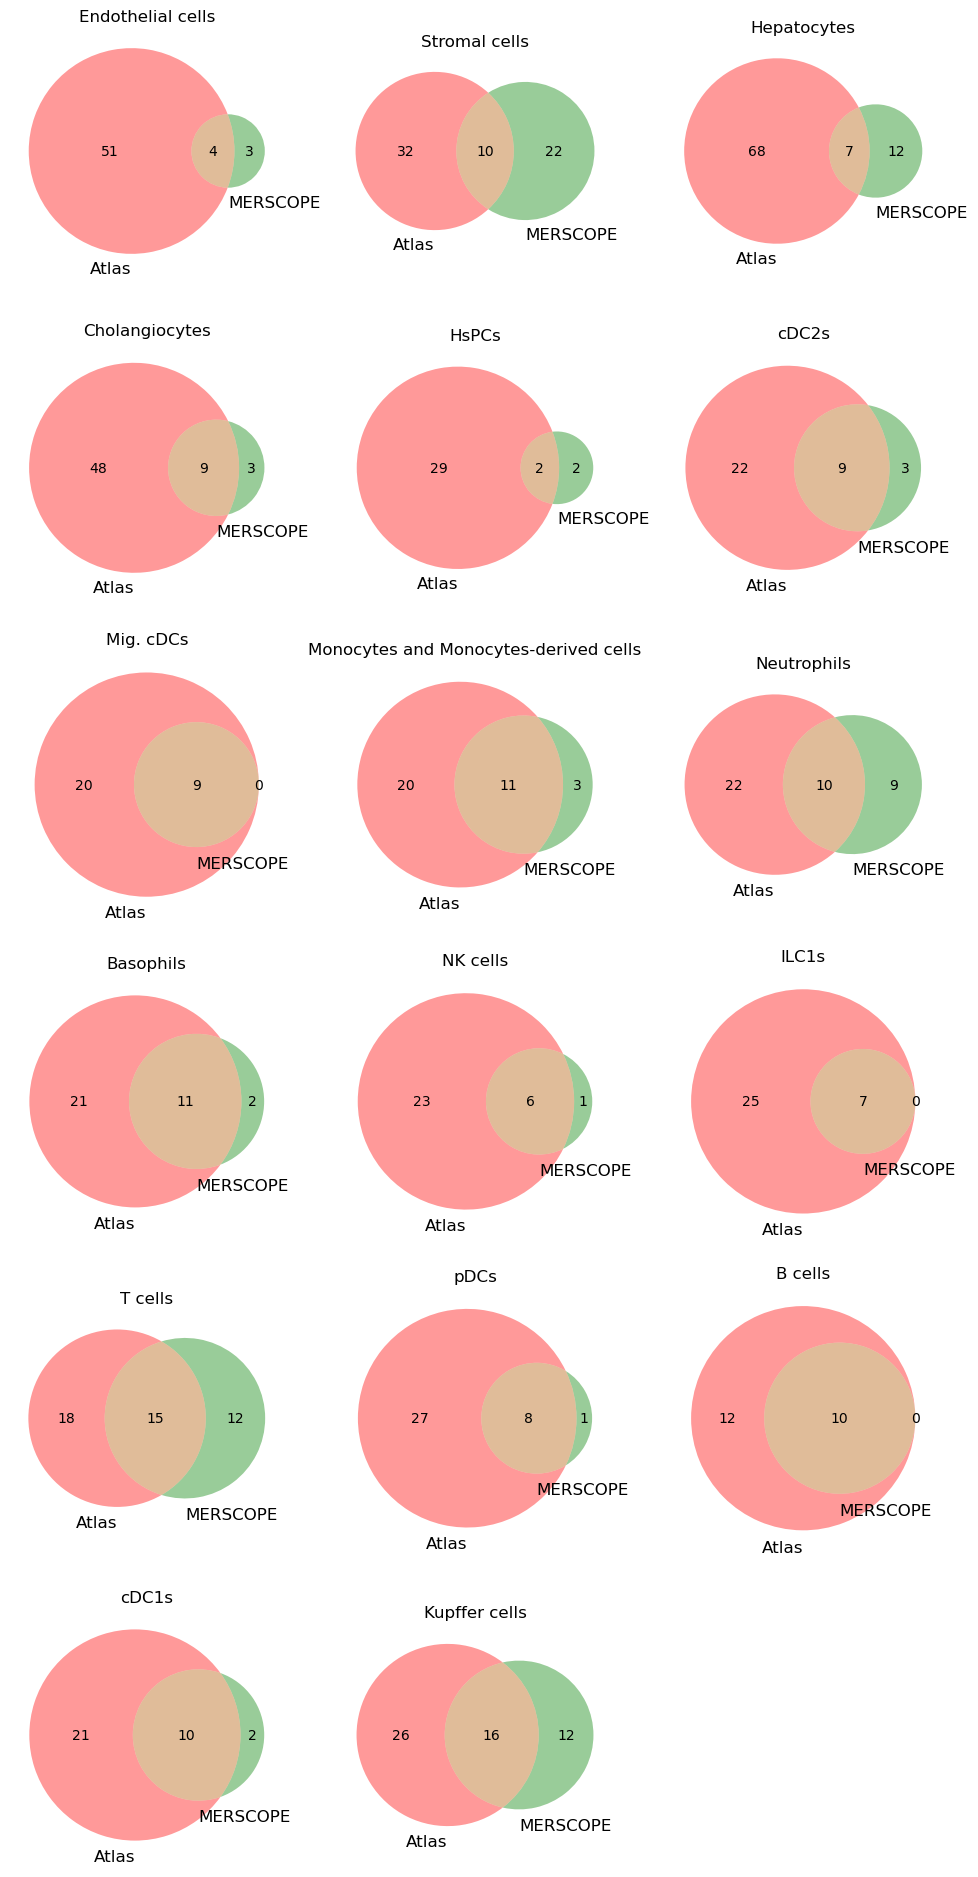

In [17]:
# We'll print out genes in the MERSCOPE panel that are missing in the atlas, and add that to our dataframe
df_onehot_merge = df_onehot.copy()

# Create a Venn diagram for each cell type as a subplot
# Create a figure with 3 columns and rows as needed
num_cell_types = len(df_onehot.columns)
num_rows = (num_cell_types + 2) // 3  # Calculate rows needed for 3 columns
fig, axes = plt.subplots(num_rows, 3, figsize=(12, 4 * num_rows))
axes = axes.flatten()

for idx, cell_type in enumerate(df_onehot.columns):
    
    if cell_type in merscope_markers_onehot.columns:
        # Get genes in both dataframes
        genes_dfTotRank = df_onehot.index[df_onehot[cell_type] == 1]
        genes_merscope = merscope_markers_onehot.index[merscope_markers_onehot[cell_type] == 1]
        
        # Find the intersection of and setdiff of genes
        intersection_genes = np.intersect1d(genes_dfTotRank, genes_merscope)
        genes_only_in_dfTotRank = np.setdiff1d(genes_dfTotRank, genes_merscope)
        genes_only_in_merscope = np.setdiff1d(genes_merscope, genes_dfTotRank)
        
        # Create a Venn diagram for each cell type
        venn2([set(genes_dfTotRank), set(genes_merscope)], ('Atlas', 'MERSCOPE'), ax=axes[idx])
        axes[idx].set_title(cell_type)

        # Hide any unused subplots
        for idx in range(len(df_onehot.columns), len(axes)):
            axes[idx].axis('off')
        
        if (len(genes_only_in_merscope) > 0):
            print(f"{len(genes_only_in_merscope)} {cell_type} genes in MERSCOPE not in atlas:")
            print(genes_only_in_merscope)
            print("")
        
        # Iterate through genes only in MERSCOPE
        for gene in genes_only_in_merscope:
            # Check if the gene already exists in dfTotRank
            if gene not in df_onehot_merge.index:
                # Add the gene to dfTotRank with all columns initialized to 0
                df_onehot_merge.loc[gene] = 0
            
            # Set the value to 1 for the corresponding cell type
            df_onehot_merge.loc[gene, cell_type] = 1

In [32]:
# Sort the gene names alphabetically
df_onehot_merge = df_onehot_merge.sort_index()

# Remove spaces and dots in the column names
df_onehot_merge.columns = df_onehot_merge.columns.str.replace(' ', '').str.replace('.', '').str.replace('-', '')

In [33]:
df_onehot_merge

,Endothelialcells,Stromalcells,Hepatocytes,Cholangiocytes,HsPCs,cDC2s,MigcDCs,MonocytesandMonocytesderivedcells,Neutrophils,Basophils,NKcells,ILC1s,Tcells,pDCs,Bcells,cDC1s,Kupffercells
0610005C13Rik,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0610031O16Rik,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1110051M20Rik,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1600010M07Rik,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1700011H14Rik,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp318,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Zfp503,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zfp512,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
Zmynd15,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [34]:
df_onehot_merge.to_csv(f'{base_path}/markers_mouseStStAll_filtered1e-2_and_merscope_onehot.csv')

In [35]:
# Check intersection of genes with VisiumHD data
adata = anndata.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr/tables/square_008um')

# Check how many genes in sdata are in common with dfTotRank_merge
genes_in_adata = df_onehot_merge.index.intersection(adata.var_names)

In [36]:
print(f"{len(genes_in_adata)} out of {df_onehot_merge.shape[0]} marker genes are present in Anndata")

# All genes are affected a little bit
pd.DataFrame({
    'All marker genes': df_onehot_merge.astype(bool).sum(axis=0),
    'Present in anndata': df_onehot_merge.loc[genes_in_adata].astype(bool).sum(axis=0)
})


1510 out of 1622 marker genes are present in Anndata


,All marker genes,Present in anndata
Endothelialcells,309,298
Stromalcells,185,182
Hepatocytes,394,355
Cholangiocytes,206,193
HsPCs,77,73
cDC2s,19,18
MigcDCs,79,77
MonocytesandMonocytesderivedcells,26,22
Neutrophils,89,78
Basophils,98,89


#### CD45- genes

Because for the deconvolution we are using the annotation that combines the StStAll and CD45- cell types, we will have to do the annotation twice as well. In `/srv/scratch/lottep/LiverMarkerGenes/CD45Neg.ipynb` the markers were just concatenated together, but I think it might be better if we do the annotation twice.

Let's investigate the intersection of the genes.

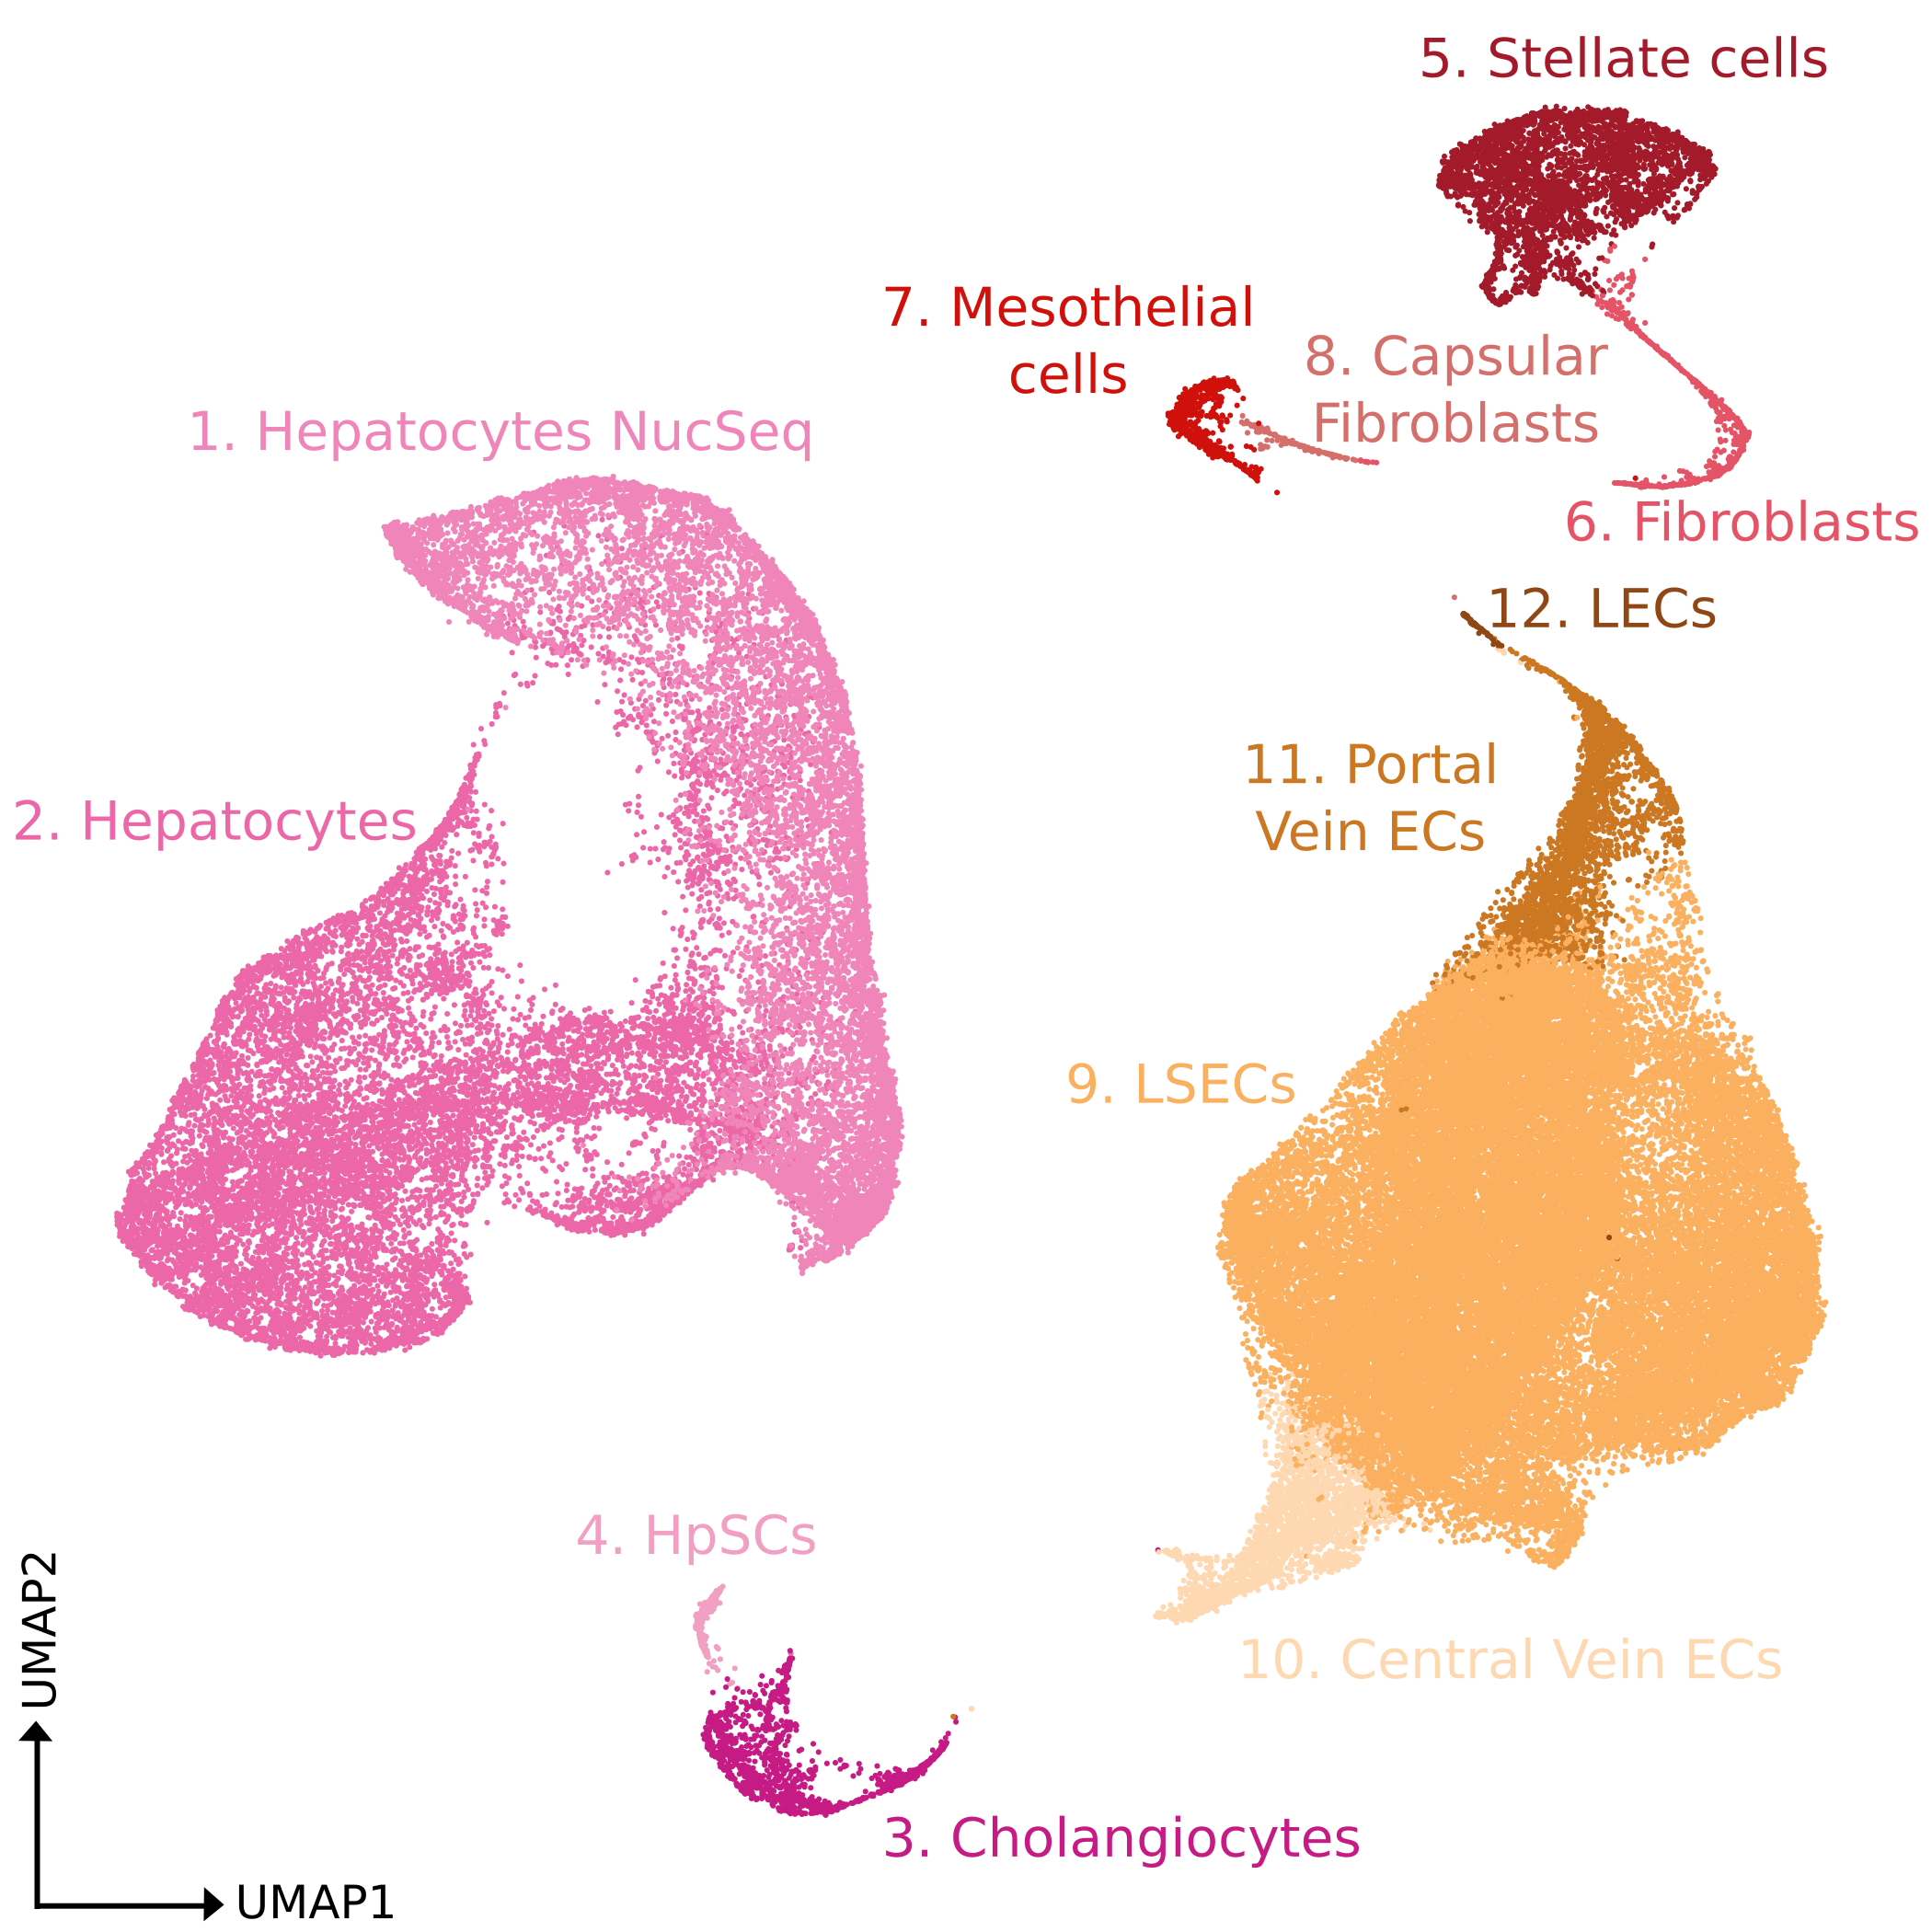

In [11]:
from IPython.display import Image
Image(filename=f'{base_path}/umap_mouseStStCD45neg.png',width=800) 

In [63]:
celltypes_cd45neg=['HepatocytesNuc', 'Hepatocytes', 'Cholangiocytes', 'HsPCs', 'Stellate cells', 'Fibroblasts',
              'Mesothelial cells', 'Capsular Fibroblasts', 'LSECs', 'Central Vein Endothelial cells', 'Portal Vein Endothelial cells',
              'Lymphatic Endothelial cells']

In [69]:
df45 = pd.read_excel(f'{base_path}/markers_mouseStStCD45neg.xlsx', index_col=0,sheet_name=None)    
geneNames45=[]
for i in df45.keys():
    geneNames45.extend(df45[i].index.values)

geneNames45=np.array(geneNames45)
indexGenes45=np.unique(geneNames45)

df45_onehot = pd.DataFrame(index = pd.Index(indexGenes45))


In [70]:
for i, cluster in enumerate(df45.keys()):
    # Initialize all columns to zero
    nameCol = celltypes_cd45neg[i]
    df45_onehot[nameCol] = 0
    
    # Set to 1 where the gene is present in the current cluster
    df45_onehot.loc[df45[cluster].index, nameCol] = 1

In [71]:
df45_onehot

,HepatocytesNuc,Hepatocytes,Cholangiocytes,HsPCs,Stellate cells,Fibroblasts,Mesothelial cells,Capsular Fibroblasts,LSECs,Central Vein Endothelial cells,Portal Vein Endothelial cells,Lymphatic Endothelial cells
0610005C13Rik,0,0,0,0,1,1,0,0,0,0,0,0
0610031O16Rik,0,0,0,0,1,1,0,0,0,0,0,0
0610040J01Rik,0,0,0,0,0,1,0,0,0,0,1,1
1110008P14Rik,0,0,0,0,1,0,0,0,0,0,0,0
1110019D14Rik,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp804b,0,0,0,0,0,0,1,0,0,0,0,0
Zfp827,0,0,0,0,0,0,0,0,0,0,1,0
Zfpm2,1,0,0,0,0,0,1,1,1,1,0,0
Zmynd15,0,0,1,0,0,0,0,0,0,0,0,0


In [72]:
# How many rows are all zeroes? (1004)
np.sum(df45_onehot.sum(axis=1) == 0)

0

,LSECs,Central Vein Endothelial cells,Portal Vein Endothelial cells,Lymphatic Endothelial cells
0610040J01Rik,0,0,1,1
1110019D14Rik,0,0,1,0
1110051M20Rik,1,1,1,1
1700011H14Rik,0,0,0,1
2310030G06Rik,0,0,0,1
...,...,...,...,...
Zfp521,1,0,0,0
Zfp618,0,0,1,1
Zfp827,0,0,1,0
Zfpm2,1,1,0,0


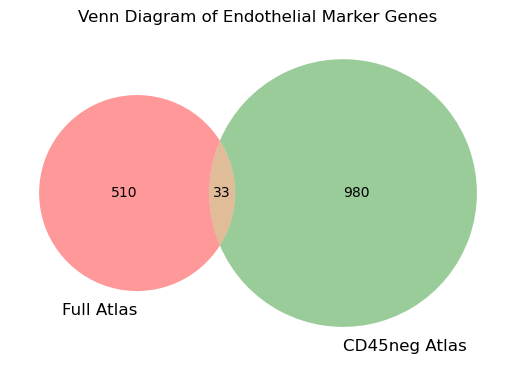

In [ ]:
# Get marker genes of endothelial cells from df_onehot and df45_onehot
ec_genes = df_onehot.loc[df_onehot.loc[:, 'Endothelial cells'] == 1]['Endothelial cells'].index.values

df45_ec = df45_onehot.loc[:, df45_onehot.columns.str.contains('Endothelial') | df45_onehot.columns.str.contains('ECs')]
df45_ec = df45_ec.loc[(df45_ec != 0).any(axis=1)]
ec45_genes = df45_ec.index.values

# Create a Venn diagram for endothelial genes
venn2([set(ec_genes), set(ec45_genes)], ('Full Atlas', 'CD45neg Atlas'))

# Add a title
plt.title("Venn Diagram of Endothelial Marker Genes")
plt.show()

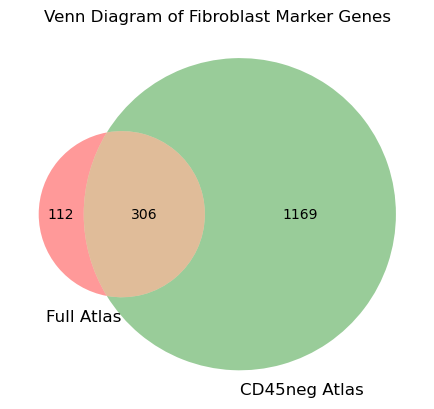

In [ ]:

# Do the same with fibroblast genes
fb_genes = df_onehot.loc[df_onehot.loc[:, 'Stromal cells'] == 1]['Stromal cells'].index.values
df45_fb = df45_onehot.loc[:, df45_onehot.columns.str.contains('Fibroblast') | df45_onehot.columns.str.contains('Mesothelial') | df45_onehot.columns.str.contains('Stellate')]
df45_fb = df45_fb.loc[(df45_fb != 0).any(axis=1)]
fb45_genes = df45_fb.index.values

# Venn diagram
venn2([set(fb_genes), set(fb45_genes)], ('Full Atlas', 'CD45neg Atlas'))

# Add a title
plt.title("Venn Diagram of Fibroblast Marker Genes")
plt.show()